# Inside the 100k-v2 rung — anatomy & why its algorithm beats v2/v3

The companion notebook (`route_experiments_100k_v2.ipynb`) shows the 100k-v2 rung
trains the **best** router within-lane (0.449 headroom, ~2.6× v3, beats v2). This
notebook opens the box: **what it's made of** (features, lanes, cells) and **why
the selection algorithm** produces a better router-training set than the old v2/v3
composers.

**The one-idea version — two rungs, not one:**

> **Rung A composes _label-blind_** (diversity coverage over cells / lanes / strata,
> no route labels in the decision) → freeze the plan → gate spend → **label only
> the selected rows** → **Rung B validates read-only**.

That inverts v2/v3, which selected the dataset **from an already-labelled pool** —
so route class drove the draw and *manufactured the very correlation the dataset
exists to measure*. Everything below is a read-only tour of the on-disk artifacts
in `src/data/rungs/100k-v2/`; nothing is re-run.

In [1]:
# Setup — read-only loads of the frozen rung artifacts (run from src/)
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
R = Path("data/rungs/100k-v2")

planned = pd.read_parquet(R / "planned_set.parquet")
trace   = pd.read_parquet(R / "selection_trace.parquet")
debt    = pd.read_parquet(R / "generation_debt.parquet")
labels  = pd.read_parquet(R / "labeling" / "labels.parquet",
                          columns=["dataset", "query_id", "route", "shape"])
summary  = json.load(open(R / "summary.json"))
coverage = json.load(open(R / "coverage_report.json"))

print(f"planned rows : {len(planned):,}  (ceiling {coverage['ceiling']:,})")
print(f"lanes        : {summary['lanes_used']}")
print(f"cells        : {planned.explode('cells').cells.nunique()}")
print(f"debt lines   : {summary['debt']}")
print(f"labelled     : {len(labels):,} (missing 0)")

planned rows : 91,093  (ceiling 100,000)
lanes        : 46
cells        : 58
debt lines   : 13
labelled     : 91,093 (missing 0)


## 1 · What's in the rung — the features

Every row carries **16 columns**, grouped by role. Note what is *absent*: there is
**no `route` / `score` / `margin` / `winner` column**. Selection literally could not
see an outcome — the labels are produced later, in a separate file (§6).

In [2]:
roles = {
    "identity":  ["row_id", "dataset", "query_id", "query"],
    "diversity axes (drive selection)":
        ["cells", "corruption_degree", "corpus_idf", "corpus_oov", "corpus_pmi",
         "provenance", "operator", "family", "home_lane"],
    "labeling bookkeeping": ["answer_covered", "answer_manifest_id", "content_fp"],
}
feature_map = pd.DataFrame(
    [(role, c) for role, cols in roles.items() for c in cols],
    columns=["role", "column"],
)
assert set(feature_map.column) == set(planned.columns), "schema drift vs plan"
print("route/score/margin column present:", any(
    c in planned.columns for c in ["route", "score", "margin", "winner"]))
feature_map

route/score/margin column present: False


,role,column
0,identity,row_id
1,identity,dataset
2,identity,query_id
3,identity,query
4,diversity axes (drive selection),cells
5,diversity axes (drive selection),corruption_degree
6,diversity axes (drive selection),corpus_idf
7,diversity axes (drive selection),corpus_oov
8,diversity axes (drive selection),corpus_pmi
9,diversity axes (drive selection),provenance


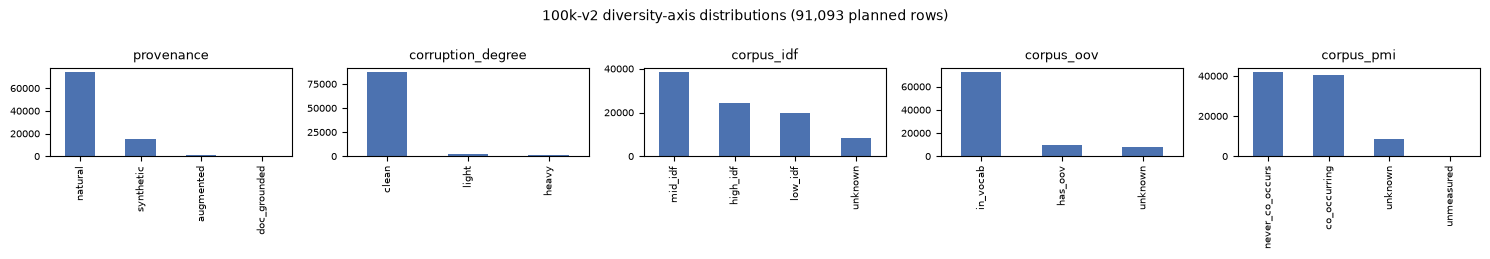

,provenance,corruption_degree,corpus_idf,corpus_oov,corpus_pmi
augmented,1177,0,0,0,0
clean,0,87563,0,0,0
co_occurring,0,0,0,0,40329
doc_grounded,243,0,0,0,0
has_oov,0,0,0,10038,0
heavy,0,1154,0,0,0
high_idf,0,0,24287,0,0
in_vocab,0,0,0,72699,0
light,0,2376,0,0,0
low_idf,0,0,19890,0,0


In [3]:
# Distributions of the categorical diversity axes
axes = ["provenance", "corruption_degree", "corpus_idf", "corpus_oov", "corpus_pmi"]
fig, ax = plt.subplots(1, len(axes), figsize=(15, 2.6))
for a, col in zip(ax, axes):
    planned[col].value_counts().plot.bar(ax=a, color="#4C72B0")
    a.set_title(col, fontsize=9); a.tick_params(labelsize=7); a.set_xlabel("")
plt.suptitle("100k-v2 diversity-axis distributions (91,093 planned rows)", fontsize=10)
plt.tight_layout(); plt.show()

pd.DataFrame({col: planned[col].value_counts() for col in axes}).fillna(0).astype(int)

## 2 · Which lanes are used

**46 lanes.** The draw is capped per lane (share cap κ), but the two largest —
`scirgen-geo-en` and `quest` — still make up ~41% of the rung because the natural
supply is bounded and they carry the most admissible queries. The long tail runs
down to the flat floor of 25 rows/lane.

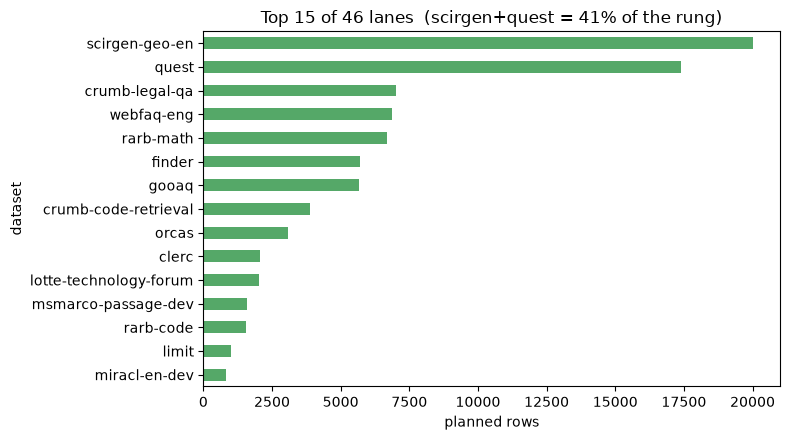

lanes total: 46 | smallest lane: 49 rows (the floor) | median lane: 196 rows


In [4]:
lane_counts = planned.dataset.value_counts()
top = lane_counts.head(15)
fig, a = plt.subplots(figsize=(8, 4.5))
top[::-1].plot.barh(ax=a, color="#55A868")
a.set_title(f"Top 15 of {lane_counts.size} lanes  "
            f"(scirgen+quest = {top.iloc[:2].sum()/len(planned):.0%} of the rung)")
a.set_xlabel("planned rows")
plt.tight_layout(); plt.show()

print(f"lanes total: {lane_counts.size} | "
      f"smallest lane: {lane_counts.min()} rows (the floor) | "
      f"median lane: {int(lane_counts.median())} rows")

## 3 · Which cells — and which are *lacking*

`cells` is a multi-label tag list: **58 distinct cells**, ~2.56 per row. A cell is a
query archetype (e.g. `rare_term_query`, `fragmented_query`) defined by band
predicates over the feature columns. The coverage floor asks for **≥25 rows per
cell**; the ones that fall short are **generation debt** — the candidate pool simply
doesn't contain enough of that shape. All 13 shortfalls are rare *structured-token*
cells (clinical codes, catalog identifiers, bare acronyms). This is the literal
answer to "which cells are lacking."

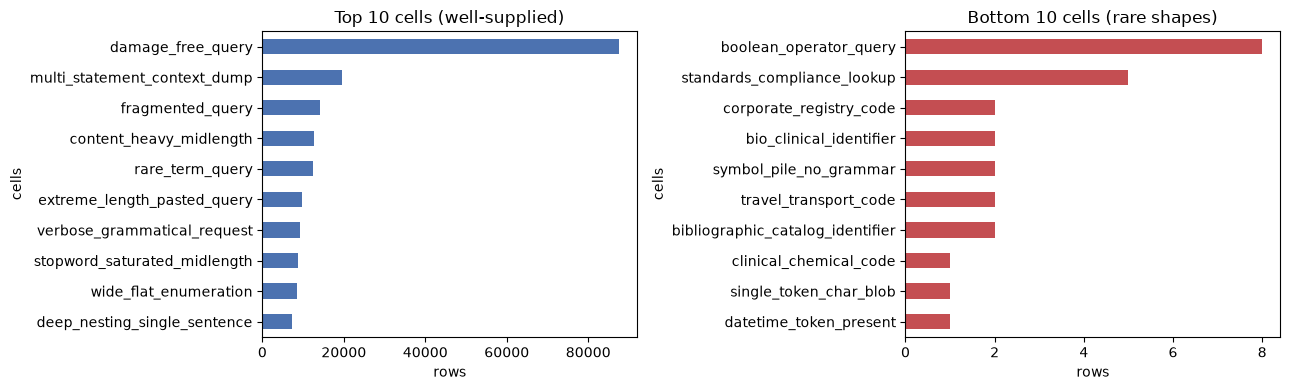

13 cells below the floor of 25 — all 'unreachable_supply':


,name,floor,admissible_supply,missing,reason
0,clinical_chemical_code,25,1,24,unreachable_supply
1,datetime_token_present,25,1,24,unreachable_supply
2,single_token_char_blob,25,1,24,unreachable_supply
3,bibliographic_catalog_identifier,25,2,23,unreachable_supply
4,bio_clinical_identifier,25,2,23,unreachable_supply
5,corporate_registry_code,25,2,23,unreachable_supply
6,symbol_pile_no_grammar,25,2,23,unreachable_supply
7,travel_transport_code,25,2,23,unreachable_supply
8,standards_compliance_lookup,25,5,20,unreachable_supply
9,boolean_operator_query,25,8,17,unreachable_supply


In [5]:
cell_counts = planned.explode("cells").cells.value_counts()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
cell_counts.head(10)[::-1].plot.barh(ax=a1, color="#4C72B0")
a1.set_title("Top 10 cells (well-supplied)"); a1.set_xlabel("rows")
cell_counts.tail(10)[::-1].plot.barh(ax=a2, color="#C44E52")
a2.set_title("Bottom 10 cells (rare shapes)"); a2.set_xlabel("rows")
plt.tight_layout(); plt.show()

# the 13 unreachable floors — the honest 'lacking cells' table
debt_view = (debt[["name", "floor", "admissible_supply", "missing", "reason"]]
             .sort_values("missing", ascending=False).reset_index(drop=True))
print(f"{len(debt)} cells below the floor of 25 — all 'unreachable_supply':")
debt_view

## 4 · How the algorithm works (`src/rungs/rung_a.py`)

Rung A is a **deterministic, label-blind greedy** loop. `_assert_shape` refuses to
even load a catalog carrying a post-label column (`route`, `margin`, `oracle`,
`winner`). Each iteration:

1. **Pick the weakest open coverage floor** — the stratum with the lowest fill
   ratio `n[k] / floor[k]`.
2. **Score every eligible candidate row** by three pre-label signals:
   - **G — structural gain** = `max over the row's strata of max(0, 1 − n_s/f_s)`
     — how much its most-starved stratum still needs.
   - **N — novelty** = `1 − max token-Jaccard vs any already-picked row in the same
     lane` — penalizes near-duplicates.
   - **Π — provenance balance** = `1 − family_count / |selected|` — down-weights an
     over-used generation family.
3. **Order lexicographically by `(−G, −N, −Π, row_id)`**, behind a **novelty gate**:
   start at θ₀ = 0.7 and step down until a candidate clears it. `row_id` is the
   deterministic final tiebreak.
4. Once all *reachable* floors are met, **`residual_fill`** takes the remaining
   capacity in `row_id` order (label-free).

**Honest read of _this_ run:** at a 91,093 plan vs a 111,111 catalog, the ceiling is
loose, so the ranking only actively *binds* on the rare-stratum coverage picks. The
`selection_trace` shows only **1.5%** of rows came in as `coverage`; the other
**98.5%** are `residual_fill`. The G/N/Π machinery is what pins the scarce cells at
25; the bulk is diversity fill under the lane caps.

selection reason:
reason
residual_fill    89744
coverage          1349

coverage picks are 1.5% of the plan

which axis each coverage pick satisfied:
stratum_axis
lane    893
cell    456


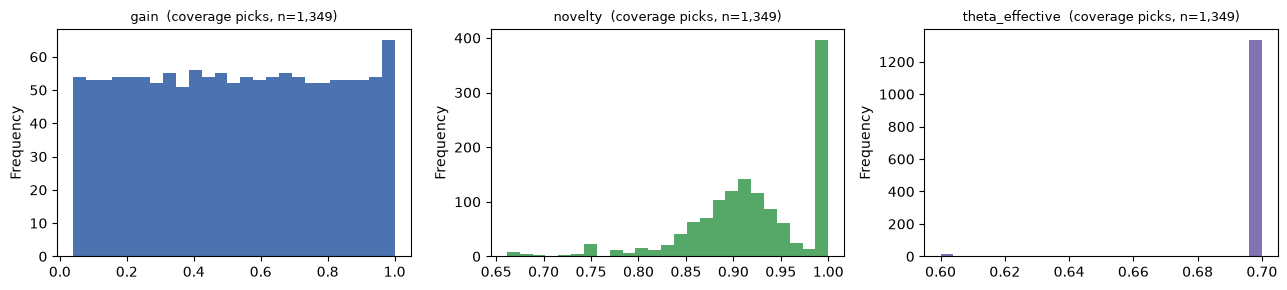


example coverage picks (rank, stratum, gain, novelty, theta):


' rank stratum_axis                stratum_name  gain  novelty  theta_effective                       lane\n    1         cell     acronym_inside_question   1.0      1.0              0.7                    antique\n    2         cell    artifact_corrupted_query   1.0      1.0              0.7                bright-aops\n    3         cell          bare_concept_token   1.0      1.0              0.7              beir-nfcorpus\n    4         cell          bare_machine_token   1.0      1.0              0.7                      gooaq\n    5         cell           bare_number_token   1.0      1.0              0.7                      orcas\n    6         cell       bare_technical_lookup   1.0      1.0              0.7                    antique\n    7         cell business_temporal_reference   1.0      1.0              0.7                     finder\n    8         cell  code_symbol_named_in_prose   1.0      1.0              0.7 bright-theoremqa-questions'

In [6]:
print("selection reason:")
print(trace.reason.value_counts().to_string())
print(f"\ncoverage picks are {trace.reason.eq('coverage').mean():.1%} of the plan")
print("\nwhich axis each coverage pick satisfied:")
print(trace[trace.reason == "coverage"].stratum_axis.value_counts().to_string())

# where the ranking signals actually vary (coverage picks) vs residual fill
cov = trace[trace.reason == "coverage"]
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
for a, col, c in zip(ax, ["gain", "novelty", "theta_effective"],
                     ["#4C72B0", "#55A868", "#8172B3"]):
    cov[col].plot.hist(ax=a, bins=25, color=c)
    a.set_title(f"{col}  (coverage picks, n={len(cov):,})", fontsize=9)
plt.tight_layout(); plt.show()

# a few coverage picks: rare cells pinned exactly at the floor
print("\nexample coverage picks (rank, stratum, gain, novelty, theta):")
cov[["rank", "stratum_axis", "stratum_name", "gain", "novelty",
     "theta_effective", "lane"]].head(8).to_string(index=False)

## 5 · Why this beats v2/v3

| | **v2 / v3** (`composer.py` + `LabelledPool`) | **rungs** (Rung A) |
|---|---|---|
| Selection universe | an **already-labelled** pool | a **label-blind** catalog |
| What drives the draw | `route_class`, `margin`, tie-taxonomy (post-label) | coverage floors (G), novelty (N), provenance (Π) — pre-label only |
| Route mix in the training set | **baked in** by construction | **observed** after the fact |
| Label cost | pay to label the whole pool, then discard "waste" | gate spend; pay only for the selected plan's cache-misses |
| Class balance | enforced at selection (45/45/10 target) | reported ±5pp band at eval; never optimized at selection |

**The core argument — no circularity.** In v3, selecting on `route_class`
"manufactures the correlation the cell exists to measure": if you pick rows because
sparse won, a router trained on them will of course find sparse-predicts-sparse. Rung
A's Rule R0 forbids the candidate's *own* outcome from entering selection, so the
route mix is an **observed property**, not a planted one. That's exactly why the
companion notebook's transfer numbers are trustworthy — the router learned a real
feature→route signal, not a selection artifact.

The cell below is the concrete proof: the frozen plan carries **no** route column,
yet the (later, separate) label file has a strongly skewed route mix that **never
touched the draw**.

In [7]:
# proof: the route mix exists only in the label file, produced AFTER selection
print("planned_set columns carrying an outcome:",
      [c for c in planned.columns if c in
       ("route", "score", "margin", "winner", "shape")] or "NONE")
print("\nroute mix in labels.parquet (produced after the plan was frozen):")
print(labels.route.value_counts(dropna=False).to_string())
print("\noutcome shape mix (the honest decomposition):")
print(labels["shape"].value_counts().to_string())
print("\n-> 47% decisive / 27% tied / 26% all-zero — a skewed outcome mix that")
print("   Rung A never saw. (The `route` column folds the 24,751 tied rows into a")
print("   sparse placeholder, so read the shape mix, not the raw route %.)")

planned_set columns carrying an outcome: NONE

route mix in labels.parquet (produced after the plan was frozen):
route
sparse_only    44747
NaN            23471
dense_only     20472
pure_rrf        2403

outcome shape mix (the honest decomposition):
shape
routes_differ    42871
all_tied         24751
all_zero         23471

-> 47% decisive / 27% tied / 26% all-zero — a skewed outcome mix that
   Rung A never saw. (The `route` column folds the 24,751 tied rows into a
   sparse placeholder, so read the shape mix, not the raw route %.)


## 6 · Honest caveats

- **`spend_check` verdict = FAIL**, but that is *not* a labeling failure — labeling
  completed 100% (0 missing). The FAIL is driven entirely by the **13 unreachable
  rare-cell floors** (§3): generation debt the pool can't satisfy. It's a signal to
  *generate more* of those shapes, not a defect in the rung.
- **The ranking bound only ~1.5% of picks here.** At this loose ceiling the G/N/Π
  ordering pins the scarce strata; the bulk is `residual_fill`. On a tighter budget
  (a smaller `N*`) the ranking would bind far more of the plan.
- **The "beats v2/v3" transfer claim is a between-build regression bar, not a final
  verdict** (SPEC d66(a)). The proper test is a paired pilot vs a class-matched
  random draw; a single run is sensitive to how the comparator is built. What this
  notebook establishes is the *mechanism* (label-blind, no circularity), not a
  significance result.